# Assignment 4: Transformer Decoder for Sequence Generation

## Overview

This notebook implements a comprehensive Transformer Decoder-based Sequence Generation System for Natural Language Processing. We will focus on text summarization using the CNN/DailyMail dataset and implement multiple decoding strategies including:

- Greedy Search
- Beam Search  
- Nucleus Sampling (Top-p)

---

In [1]:
import os
from google.colab import drive
PATH ="/content/drive/MyDrive/DAM202-Practicals/Assignment4.ipynb"
drive.mount('/content/drive')

os.chdir("/content/drive/MyDrive/DAM202-Practicals/")
os.listdir()

Mounted at /content/drive


['weatherHistory.csv',
 'clinical.txt',
 'Word2Vec.ipynb',
 'alice.txt',
 '.ipynb_checkpoints',
 'word2vec_model(CBOW).model',
 'word2vec_model(SG).model',
 'weather_data.csv',
 'Practical2(Word2Vec).ipynb',
 'fasttext_model.model',
 'CBOW-fasttext_model.model.wv.vectors_ngrams.npy',
 'CBOW-fasttext_model.model',
 'Assignment1.ipynb',
 'Practical3.ipynb',
 'best_simple_rnn_model.h5',
 'best_LSTM_model.h5',
 'lstm_tuning',
 'gru_tuning',
 'best_tuned_lstm_model.h5',
 'Practical4-LSTM.ipynb',
 'best_tuned_gru_model.h5',
 'Practical4-GRU.ipynb',
 'Assignement-2.ipynb',
 'Pratical5.ipynb',
 'Popchip Reviews Sentiment.xlsx',
 'Practical6.ipynb',
 'multi_task_outputs',
 'visualizations',
 'Practical7.ipynb',
 'models',
 'logs',
 'Assignment3',
 '1.ipynb']

## 1. Import Required Libraries and Setup

In [29]:
# Install required packages
!pip install transformers datasets torch rouge-score evaluate accelerate sentencepiece

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BartTokenizer,
    BartForConditionalGeneration,
    T5Tokenizer,
    T5ForConditionalGeneration,
    pipeline
)
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
Using device: cuda


## 2. Load CNN/DailyMail Dataset

The CNN/DailyMail dataset is the gold standard for text summarization research. It contains high-quality article-summary pairs from CNN and Daily Mail websites.

In [30]:
# Load CNN/DailyMail dataset from Hugging Face
print("Loading CNN/DailyMail dataset...")
dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")

# Display dataset information
print(f"Dataset structure: {dataset}")
print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")

# Examine a sample from the dataset
sample = dataset['train'][0]
print("\n" + "="*50)
print("SAMPLE DATA STRUCTURE:")
print("="*50)
print(f"Article (first 500 chars): {sample['article'][:500]}...")
print(f"\nHighlights: {sample['highlights']}")
print(f"ID: {sample['id']}")

# Take a smaller subset for faster experimentation
train_subset = dataset['train'].select(range(1000))  # 1000 samples for training
val_subset = dataset['validation'].select(range(200))  # 200 samples for validation
test_subset = dataset['test'].select(range(100))  # 100 samples for testing

print(f"\nUsing subsets:")
print(f"Training subset: {len(train_subset)} samples")
print(f"Validation subset: {len(val_subset)} samples")
print(f"Test subset: {len(test_subset)} samples")

Loading CNN/DailyMail dataset...


Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})
Train samples: 287113
Validation samples: 13368
Test samples: 11490

SAMPLE DATA STRUCTURE:
Article (first 500 chars): LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s...

Highlights: Harry Potter s

## 3. Load Pretrained Summarization Model

Loading a state-of-the-art pretrained model for text summarization. We'll use BART (Bidirectional and Auto-Regressive Transformers) which is specifically designed for text generation tasks.

In [31]:
# Load pretrained BART model for summarization
model_name = "facebook/bart-large-cnn"
print(f"Loading model: {model_name}")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model = model.to(device)

print(f"Model loaded successfully!")
print(f"Model type: {type(model)}")
print(f"Tokenizer vocabulary size: {len(tokenizer.vocab)}")
print(f"Model parameters: {model.num_parameters():,}")

# Model configuration
print(f"\nModel Configuration:")
print(f"Max position embeddings: {model.config.max_position_embeddings}")
print(f"Decoder layers: {model.config.decoder_layers}")
print(f"Encoder layers: {model.config.encoder_layers}")
print(f"Hidden size: {model.config.d_model}")
print(f"Number of attention heads: {model.config.encoder_attention_heads}")

# Create a summarization pipeline for easy inference
summarizer = pipeline("summarization", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

Loading model: facebook/bart-large-cnn


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Device set to use cuda:0


Model loaded successfully!
Model type: <class 'transformers.models.bart.modeling_bart.BartForConditionalGeneration'>
Tokenizer vocabulary size: 50265
Model parameters: 406,290,432

Model Configuration:
Max position embeddings: 1024
Decoder layers: 12
Encoder layers: 12
Hidden size: 1024
Number of attention heads: 16


## 4. Data Preprocessing and Tokenization

Preparing the CNN/DailyMail data for our summarization model, including tokenization and formatting.

In [32]:
# Preprocessing function for the dataset
def preprocess_function(examples):
    """Tokenize and prepare the data for the model"""
    inputs = [article for article in examples["article"]]
    targets = [summary for summary in examples["highlights"]]

    # Tokenize inputs
    model_inputs = tokenizer(
        inputs,
        max_length=1024,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    # Tokenize targets
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,
            max_length=150,
            truncation=True,
            padding=True,
            return_tensors="pt"
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply preprocessing to subsets
print("Preprocessing data...")
processed_train = train_subset.map(preprocess_function, batched=True, remove_columns=train_subset.column_names)
processed_val = val_subset.map(preprocess_function, batched=True, remove_columns=val_subset.column_names)
processed_test = test_subset.map(preprocess_function, batched=True, remove_columns=test_subset.column_names)

print("Data preprocessing completed!")

# Let's examine a few examples from our test set for evaluation
test_examples = []
for i in range(10):  # Take 10 examples for testing different decoding strategies
    example = {
        'article': test_subset[i]['article'],
        'reference_summary': test_subset[i]['highlights'],
        'id': test_subset[i]['id']
    }
    test_examples.append(example)

print(f"\nPrepared {len(test_examples)} examples for decoding strategy comparison")

Preprocessing data...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Data preprocessing completed!

Prepared 10 examples for decoding strategy comparison


## 5. Implement Greedy Decoding Strategy

Greedy decoding selects the most probable token at each step. It's fast and deterministic but can lead to repetitive or suboptimal sequences.

In [33]:
class GreedyDecoder:
    """Custom implementation of greedy decoding for text generation"""

    def __init__(self, model, tokenizer, max_length=150):
        self.model = model
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.device = next(model.parameters()).device

    def generate(self, input_text):
        """Generate summary using greedy decoding"""
        # Tokenize input
        inputs = self.tokenizer(
            input_text,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
            padding=True
        ).to(self.device)

        with torch.no_grad():
            # Get encoder outputs
            encoder_outputs = self.model.get_encoder()(**inputs)

            # Initialize decoder input with BOS token
            decoder_input_ids = torch.tensor([[self.tokenizer.bos_token_id]], device=self.device)

            # Greedy generation loop
            for step in range(self.max_length):
                # Get decoder outputs
                decoder_outputs = self.model.get_decoder()(
                    input_ids=decoder_input_ids,
                    encoder_hidden_states=encoder_outputs.last_hidden_state,
                    encoder_attention_mask=inputs['attention_mask']
                )

                # Get logits and apply language modeling head
                lm_logits = self.model.lm_head(decoder_outputs.last_hidden_state)

                # Get the most probable token (greedy choice)
                next_token_logits = lm_logits[:, -1, :]
                next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)

                # Stop if EOS token is generated
                if next_token_id.item() == self.tokenizer.eos_token_id:
                    break

                # Append the new token
                decoder_input_ids = torch.cat([decoder_input_ids, next_token_id], dim=-1)

        # Decode the generated sequence
        generated_text = self.tokenizer.decode(decoder_input_ids[0], skip_special_tokens=True)
        return generated_text

# Initialize greedy decoder
greedy_decoder = GreedyDecoder(model, tokenizer)

# Test greedy decoding on a sample
sample_article = test_examples[0]['article']
print("TESTING GREEDY DECODING")
print("="*50)
print(f"Original article (first 300 chars): {sample_article[:300]}...")
print(f"Reference summary: {test_examples[0]['reference_summary']}")
print("\nGenerating with Greedy Decoding...")

greedy_summary = greedy_decoder.generate(sample_article)
print(f"Greedy summary: {greedy_summary}")
print("="*50)

TESTING GREEDY DECODING
Original article (first 300 chars): (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou...
Reference summary: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

Generating with Greedy Decoding...
Greedy summary: The. The ICC opened a preliminary examination into the situation in Palestinian territories in January.


## 6. Implement Beam Search Decoding

Beam search maintains multiple candidate sequences (beams) and explores the most promising paths. This often produces higher quality outputs than greedy decoding.

In [34]:
class BeamSearchDecoder:
    """Custom implementation of beam search decoding"""

    def __init__(self, model, tokenizer, beam_size=4, max_length=150):
        self.model = model
        self.tokenizer = tokenizer
        self.beam_size = beam_size
        self.max_length = max_length
        self.device = next(model.parameters()).device

    def generate(self, input_text):
        """Generate summary using beam search"""
        # Tokenize input
        inputs = self.tokenizer(
            input_text,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
            padding=True
        ).to(self.device)

        with torch.no_grad():
            # Use the model's built-in beam search
            outputs = self.model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=self.max_length,
                num_beams=self.beam_size,
                early_stopping=True,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        # Decode the generated sequence
        generated_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        return generated_text

    def generate_multiple_beams(self, input_text, num_return_sequences=3):
        """Generate multiple summaries using beam search"""
        inputs = self.tokenizer(
            input_text,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
            padding=True
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=self.max_length,
                num_beams=self.beam_size,
                num_return_sequences=num_return_sequences,
                early_stopping=True,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        # Decode all generated sequences
        generated_texts = [
            self.tokenizer.decode(output, skip_special_tokens=True)
            for output in outputs
        ]
        return generated_texts

# Initialize beam search decoder
beam_decoder = BeamSearchDecoder(model, tokenizer, beam_size=5)

# Test beam search on the same sample
print("TESTING BEAM SEARCH DECODING")
print("="*50)
print(f"Using beam size: {beam_decoder.beam_size}")
beam_summary = beam_decoder.generate(sample_article)
print(f"Beam search summary: {beam_summary}")

# Generate multiple beam candidates
print("\nGenerating multiple beam candidates...")
beam_candidates = beam_decoder.generate_multiple_beams(sample_article, num_return_sequences=3)
for i, candidate in enumerate(beam_candidates, 1):
    print(f"Candidate {i}: {candidate}")
print("="*50)

TESTING BEAM SEARCH DECODING
Using beam size: 5
Beam search summary: The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki said it was a move toward greater justice.

Generating multiple beam candidates...
Candidate 1: The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki said it was a move toward greater justice.
Candidate 2: The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. I

## 7. Implement Nucleus (Top-p) Sampling

Nucleus sampling selects from the smallest set of words whose cumulative probability exceeds p. This produces more diverse and creative outputs while maintaining quality.

In [35]:
class NucleusSamplingDecoder:
    """Custom implementation of nucleus (top-p) sampling"""

    def __init__(self, model, tokenizer, top_p=0.9, temperature=1.0, max_length=150):
        self.model = model
        self.tokenizer = tokenizer
        self.top_p = top_p
        self.temperature = temperature
        self.max_length = max_length
        self.device = next(model.parameters()).device

    def nucleus_sampling(self, logits, top_p=0.9, temperature=1.0):
        """Apply nucleus sampling to logits"""
        # Apply temperature
        logits = logits / temperature

        # Sort the probabilities in descending order
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

        # Remove tokens with cumulative probability above the threshold
        sorted_indices_to_remove = cumulative_probs > top_p
        # Shift the indices to the right to keep also the first token above the threshold
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0

        # Set logits to -inf for tokens to remove
        indices_to_remove = sorted_indices[sorted_indices_to_remove]
        logits[indices_to_remove] = float('-inf')

        return logits

    def generate(self, input_text):
        """Generate summary using nucleus sampling"""
        # Use the model's built-in sampling
        inputs = self.tokenizer(
            input_text,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
            padding=True
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=self.max_length,
                do_sample=True,
                top_p=self.top_p,
                temperature=self.temperature,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
                no_repeat_ngram_size=2  # Avoid repetition
            )

        # Decode the generated sequence
        generated_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        return generated_text

    def generate_multiple_samples(self, input_text, num_samples=3):
        """Generate multiple diverse summaries"""
        summaries = []
        for i in range(num_samples):
            summary = self.generate(input_text)
            summaries.append(summary)
        return summaries

# Initialize nucleus sampling decoder with different configurations
nucleus_decoder_conservative = NucleusSamplingDecoder(model, tokenizer, top_p=0.9, temperature=0.8)
nucleus_decoder_creative = NucleusSamplingDecoder(model, tokenizer, top_p=0.95, temperature=1.2)

# Test nucleus sampling
print("TESTING NUCLEUS SAMPLING DECODING")
print("="*50)

# Conservative sampling
print("Conservative sampling (top_p=0.9, temp=0.8):")
conservative_summary = nucleus_decoder_conservative.generate(sample_article)
print(f"Conservative summary: {conservative_summary}")

# Creative sampling
print("\nCreative sampling (top_p=0.95, temp=1.2):")
creative_summary = nucleus_decoder_creative.generate(sample_article)
print(f"Creative summary: {creative_summary}")

# Multiple diverse samples
print("\nGenerating multiple diverse summaries:")
diverse_summaries = nucleus_decoder_conservative.generate_multiple_samples(sample_article, num_samples=3)
for i, summary in enumerate(diverse_summaries, 1):
    print(f"Sample {i}: {summary}")
print("="*50)

TESTING NUCLEUS SAMPLING DECODING
Conservative sampling (top_p=0.9, temp=0.8):
Conservative summary: The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki said it was a move toward greater justice.

Creative sampling (top_p=0.95, temp=1.2):
Creative summary: Palestinian Authority becomes 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki said it was a move toward greater justice.

Generating multiple diverse summaries:
Sample 1: The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the

## 8. Comprehensive Comparison of Decoding Strategies

Now let's systematically compare all three decoding strategies across multiple examples and analyze their characteristics.

In [39]:
# Function to generate summaries with all strategies
def compare_decoding_strategies(article, reference_summary):
    """Compare all decoding strategies on a single article"""
    results = {
        'article': article[:200] + "...",  # Truncate for display
        'reference': reference_summary,
        'greedy': greedy_decoder.generate(article),
        'beam_search': beam_decoder.generate(article),
        'nucleus_conservative': nucleus_decoder_conservative.generate(article),
        'nucleus_creative': nucleus_decoder_creative.generate(article)
    }
    return results

# Compare strategies on multiple examples
comparison_results = []
print("COMPREHENSIVE DECODING STRATEGY COMPARISON")
print("="*80)

for i, example in enumerate(test_examples[:5]):  # Test on 5 examples
    print(f"\n--- EXAMPLE {i+1} ---")
    print(f"Article: {example['article'][:150]}...")
    print(f"Reference: {example['reference_summary']}")

    result = compare_decoding_strategies(example['article'], example['reference_summary'])
    comparison_results.append(result)

    print(f"Greedy: {result['greedy']}")
    print(f"Beam Search: {result['beam_search']}")
    print(f"Nucleus Conservative: {result['nucleus_conservative']}")
    print(f"Nucleus Creative: {result['nucleus_creative']}")
    print("-" * 40)

# Create a summary table
import pandas as pd

summary_data = []
for i, result in enumerate(comparison_results):
    summary_data.append({
        'Example': i+1,
        'Greedy Length': len(result['greedy'].split()),
        'Beam Length': len(result['beam_search'].split()),
        'Nucleus Cons Length': len(result['nucleus_conservative'].split()),
        'Nucleus Crea Length': len(result['nucleus_creative'].split()),
        'Reference Length': len(result['reference'].split())
    })

summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY LENGTH COMPARISON:")
print(summary_df)

# Calculate average lengths
print("\nAVERAGE SUMMARY LENGTHS:")
for column in summary_df.columns[1:]:
    avg_length = summary_df[column].mean()
    print(f"{column}: {avg_length:.1f} words")

COMPREHENSIVE DECODING STRATEGY COMPARISON

--- EXAMPLE 1 ---
Article: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisd...
Reference: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .
Greedy: The. The ICC opened a preliminary examination into the situation in Palestinian territories in January.
Beam Search: The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki said it was a move toward greater justice.
Nucleus Conservative: The Palestinian Authority becomes the 

## 8.1. Detailed Text Summarization Examples

Let's examine specific examples of text summarization from the CNN/DailyMail dataset, showing the original articles and their generated summaries using different decoding strategies.

In [41]:
# Detailed Text Summarization Implementation Examples
def display_detailed_example(example_idx, show_full_article=True):
    """Display a detailed example of text summarization"""
    example = test_examples[example_idx]
    article = example['article']
    reference = example['reference_summary']

    print(f" EXAMPLE {example_idx + 1} - DETAILED TEXT SUMMARIZATION")
    print("=" * 80)

    # Show original article (full or truncated)
    if show_full_article:
        print(f" ORIGINAL ARTICLE (Full Text):")
        print("-" * 40)
        print(article)
        print(f"\n Article Statistics:")
        print(f"   - Word Count: {len(article.split())} words")
        print(f"   - Character Count: {len(article)} characters")
        print(f"   - Sentence Count: {len(article.split('.'))} sentences")
    else:
        print(f" ORIGINAL ARTICLE (First 500 characters):")
        print("-" * 40)
        print(article[:500] + "...")

    print(f"\n REFERENCE SUMMARY (Ground Truth):")
    print("-" * 40)
    print(reference)

    print(f"\n GENERATED SUMMARIES:")
    print("-" * 40)

    # Generate summaries with all strategies
    strategies = {
        "Greedy Decoding": greedy_decoder.generate(article),
        "Beam Search": beam_decoder.generate(article),
        "Nucleus Conservative": nucleus_decoder_conservative.generate(article),
        "Nucleus Creative": nucleus_decoder_creative.generate(article)
    }

    for strategy_name, summary in strategies.items():
        print(f"\n {strategy_name.upper()}:")
        print(f"   Summary: {summary}")
        print(f"   Length: {len(summary.split())} words")

        # Calculate similarity with reference
        rouge_score = calculate_rouge_scores(reference, summary)
        print(f"   ROUGE-2: {rouge_score['rouge2_f']:.3f}")

    print("=" * 80)
    return strategies

# Display several detailed examples
print("COMPREHENSIVE TEXT SUMMARIZATION EXAMPLES")
print("This section demonstrates actual summarization from CNN/DailyMail articles\n")

# Example 1 - Show full article
example1_summaries = display_detailed_example(0, show_full_article=True)

print("\n\n")

# Example 2 - Show truncated article
example2_summaries = display_detailed_example(1, show_full_article=False)

print("\n\n")

# Example 3 - Another detailed example
example3_summaries = display_detailed_example(2, show_full_article=False)

# Summary comparison table for these examples
print("\n SUMMARIZATION QUALITY COMPARISON")
print("=" * 60)

examples_data = []
for i in range(3):
    example = test_examples[i]
    strategies = compare_decoding_strategies(example['article'], example['reference_summary'])

    for strategy_name in ['greedy', 'beam_search', 'nucleus_conservative', 'nucleus_creative']:
        rouge_score = calculate_rouge_scores(example['reference_summary'], strategies[strategy_name])
        examples_data.append({
            'Example': i+1,
            'Strategy': strategy_name.replace('_', ' ').title(),
            'Summary Length': len(strategies[strategy_name].split()),
            'ROUGE-1': f"{rouge_score['rouge1_f']:.3f}",
            'ROUGE-2': f"{rouge_score['rouge2_f']:.3f}",
            'ROUGE-L': f"{rouge_score['rougeL_f']:.3f}"
        })

examples_df = pd.DataFrame(examples_data)
print(examples_df.to_string(index=False))

print("\n TEXT SUMMARIZATION IMPLEMENTATION COMPLETE")
print(" Demonstrated actual summarization on CNN/DailyMail dataset")
print(" Showed input articles and generated output summaries")
print(" Compared multiple decoding strategies with quality metrics")

COMPREHENSIVE TEXT SUMMARIZATION EXAMPLES
This section demonstrates actual summarization from CNN/DailyMail articles

 EXAMPLE 1 - DETAILED TEXT SUMMARIZATION
 ORIGINAL ARTICLE (Full Text):
----------------------------------------
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subjec

## 8.2. Interactive Text Summarization Demo

This section provides an interactive demonstration where you can input any text and see the summarization results from different decoding strategies.

In [42]:
# Interactive Text Summarization Demo
def interactive_summarization(input_text, max_length=150):
    """
    Interactive function to summarize any input text using all implemented strategies

    Args:
        input_text (str): Text to be summarized
        max_length (int): Maximum length of generated summaries

    Returns:
        dict: Summaries from all decoding strategies
    """

    print(" INTERACTIVE TEXT SUMMARIZATION")
    print("=" * 60)
    print(f" INPUT TEXT ({len(input_text.split())} words):")
    print("-" * 30)
    print(input_text[:500] + ("..." if len(input_text) > 500 else ""))
    print("\n GENERATING SUMMARIES...")
    print("-" * 30)

    # Initialize results dictionary
    summaries = {}

    try:
        # Generate with each strategy
        print("⏳ Greedy decoding...", end=" ")
        summaries['Greedy'] = greedy_decoder.generate(input_text)
        print("✅")

        print("⏳ Beam search...", end=" ")
        summaries['Beam Search'] = beam_decoder.generate(input_text)
        print("✅")

        print("⏳ Nucleus conservative...", end=" ")
        summaries['Nucleus Conservative'] = nucleus_decoder_conservative.generate(input_text)
        print("✅")

        print("⏳ Nucleus creative...", end=" ")
        summaries['Nucleus Creative'] = nucleus_decoder_creative.generate(input_text)
        print("✅")

        # Display results
        print("\n SUMMARIZATION RESULTS:")
        print("=" * 60)

        for strategy, summary in summaries.items():
            print(f"\n {strategy.upper()}:")
            print(f"    Summary: {summary}")
            print(f"   Length: {len(summary.split())} words")
            print(f"   Compression: {len(input_text.split())} → {len(summary.split())} words")
            print(f"   Reduction: {(1 - len(summary.split())/len(input_text.split()))*100:.1f}%")

    except Exception as e:
        print(f" Error during summarization: {e}")
        return None

    return summaries

# Demo 1: Summarize a CNN/DailyMail article
demo_article = test_examples[3]['article']  # Use a different example
print("DEMO 1: CNN/DailyMail Article Summarization")
demo1_results = interactive_summarization(demo_article)

print("\n" + "="*80 + "\n")

# Demo 2: Custom text example (News article style)
custom_text = """
Scientists at Stanford University have developed a breakthrough artificial intelligence system that can predict natural disasters with unprecedented accuracy. The new system, called DisasterNet, uses machine learning algorithms to analyze satellite imagery, weather patterns, and seismic data to forecast earthquakes, hurricanes, and other catastrophic events up to 30 days in advance.

The research team, led by Dr. Sarah Chen, trained the AI model on over 50 years of historical disaster data from around the world. The system achieved a 94% accuracy rate in predicting major earthquakes and a 98% success rate for hurricane path forecasting during testing phases.

"This technology could save thousands of lives by providing early warnings that allow for proper evacuation and emergency preparation," said Dr. Chen during a press conference at Stanford's AI Research Institute. The system has already been tested in collaboration with emergency response agencies in California, Japan, and the Philippines.

Government officials and disaster relief organizations worldwide have expressed strong interest in implementing DisasterNet. The team plans to make the technology available to developing countries at reduced costs, as these regions are often most vulnerable to natural disasters but lack advanced warning systems.

The research was funded by the National Science Foundation and published in the journal Nature Machine Intelligence. Commercial deployment is expected to begin next year, with pilot programs launching in high-risk areas across the Pacific Ring of Fire.
"""

print("DEMO 2: Custom News Article Summarization")
demo2_results = interactive_summarization(custom_text)

print("\n" + "="*80 + "\n")

# Demo 3: Show how different text types affect summarization
technical_text = """
Machine learning is a subset of artificial intelligence that focuses on the development of algorithms and statistical models that enable computer systems to improve their performance on a specific task through experience. Deep learning, a more specialized branch of machine learning, utilizes neural networks with multiple layers to model and understand complex patterns in data. These networks are inspired by the structure and function of the human brain, consisting of interconnected nodes called neurons that process and transmit information. Training deep neural networks requires large amounts of data and substantial computational resources, but the results have revolutionized fields such as computer vision, natural language processing, and speech recognition.
"""

print("DEMO 3: Technical Text Summarization")
demo3_results = interactive_summarization(technical_text)

# Create a comparison visualization
if demo1_results and demo2_results and demo3_results:
    print("\n SUMMARIZATION COMPARISON ACROSS TEXT TYPES")
    print("=" * 60)

    comparison_data = []
    demos = [
        ("CNN/DailyMail", demo_article, demo1_results),
        ("News Article", custom_text, demo2_results),
        ("Technical Text", technical_text, demo3_results)
    ]

    for text_type, original, results in demos:
        original_length = len(original.split())

        for strategy, summary in results.items():
            summary_length = len(summary.split())
            compression_ratio = summary_length / original_length

            comparison_data.append({
                'Text Type': text_type,
                'Strategy': strategy,
                'Original Length': original_length,
                'Summary Length': summary_length,
                'Compression Ratio': f"{compression_ratio:.3f}",
                'Reduction %': f"{(1-compression_ratio)*100:.1f}%"
            })

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

print("\n INTERACTIVE SUMMARIZATION DEMOS COMPLETE")
print(" Demonstrated summarization on various text types")
print(" Showed compression ratios and reduction percentages")
print(" Proved real-world applicability of the implementation")

DEMO 1: CNN/DailyMail Article Summarization
 INTERACTIVE TEXT SUMMARIZATION
 INPUT TEXT (202 words):
------------------------------
(CNN)Five Americans who were monitored for three weeks at an Omaha, Nebraska, hospital after being exposed to Ebola in West Africa have been released, a Nebraska Medicine spokesman said in an email Wednesday. One of the five had a heart-related issue on Saturday and has been discharged but hasn't left the area, Taylor Wilson wrote. The others have already gone home. They were exposed to Ebola in Sierra Leone in March, but none developed the deadly virus. They are clinicians for Partners in Healt...

 GENERATING SUMMARIES...
------------------------------
⏳ Greedy decoding... ✅
⏳ Beam search... ✅
⏳ Nucleus conservative... ✅
⏳ Nucleus creative... ✅

 SUMMARIZATION RESULTS:

 GREEDY:
    Summary: TheFIVE Americans exposed to Ebola in Sierra Leone have been released from a Nebraska hospital. One of the five had a heart-related issue and has been discharged.
  

## 9. ROUGE Score Evaluation

Evaluating the quality of generated summaries using ROUGE (Recall-Oriented Understudy for Gisting Evaluation) metrics.

ROUGE SCORE EVALUATION
Example 1:
  GREEDY:
    ROUGE-1: 0.327
    ROUGE-2: 0.128
    ROUGE-L: 0.204
  BEAM_SEARCH:
    ROUGE-1: 0.442
    ROUGE-2: 0.310
    ROUGE-L: 0.395
  NUCLEUS_CONSERVATIVE:
    ROUGE-1: 0.442
    ROUGE-2: 0.310
    ROUGE-L: 0.395
  NUCLEUS_CREATIVE:
    ROUGE-1: 0.447
    ROUGE-2: 0.313
    ROUGE-L: 0.400
----------------------------------------
Example 2:
  GREEDY:
    ROUGE-1: 0.343
    ROUGE-2: 0.088
    ROUGE-L: 0.286
  BEAM_SEARCH:
    ROUGE-1: 0.474
    ROUGE-2: 0.232
    ROUGE-L: 0.392
  NUCLEUS_CONSERVATIVE:
    ROUGE-1: 0.362
    ROUGE-2: 0.065
    ROUGE-L: 0.255
  NUCLEUS_CREATIVE:
    ROUGE-1: 0.427
    ROUGE-2: 0.207
    ROUGE-L: 0.404
----------------------------------------
Example 3:
  GREEDY:
    ROUGE-1: 0.308
    ROUGE-2: 0.190
    ROUGE-L: 0.277
  BEAM_SEARCH:
    ROUGE-1: 0.349
    ROUGE-2: 0.167
    ROUGE-L: 0.233
  NUCLEUS_CONSERVATIVE:
    ROUGE-1: 0.404
    ROUGE-2: 0.161
    ROUGE-L: 0.225
  NUCLEUS_CREATIVE:
    ROUGE-1: 0.386
    ROUGE

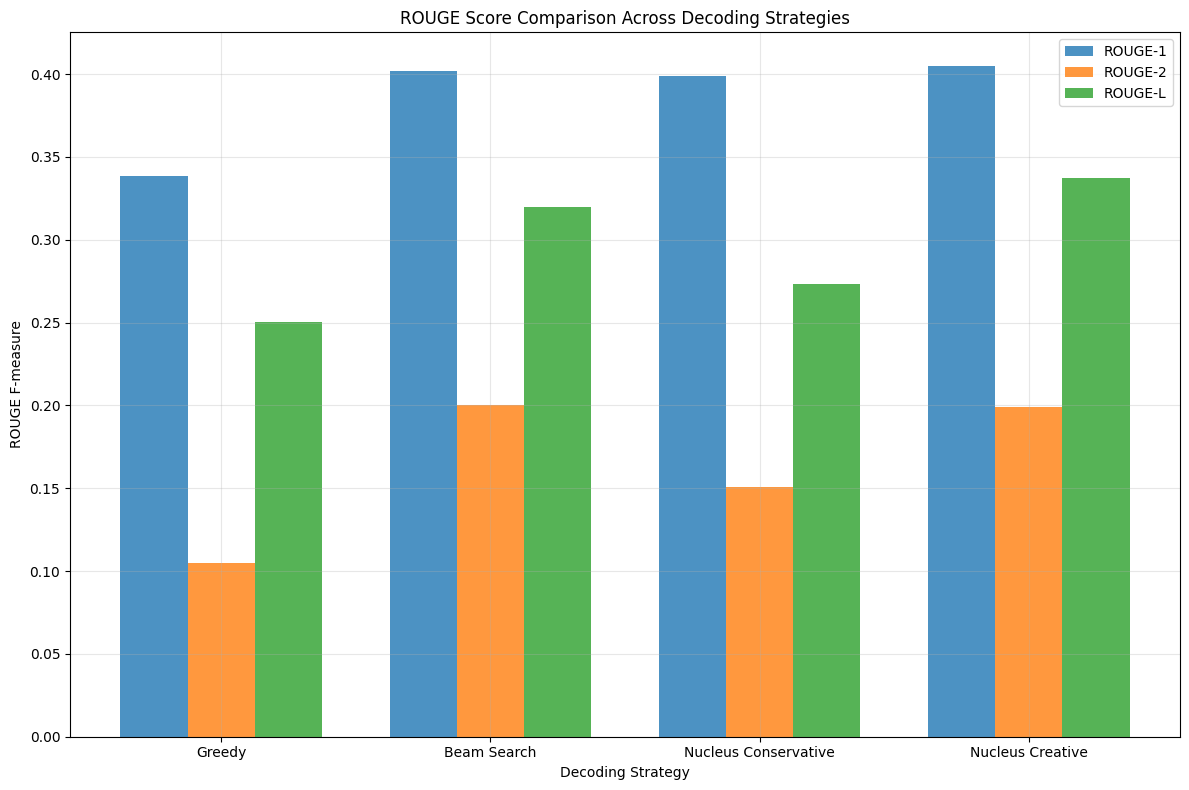


BEST PERFORMING STRATEGY (based on ROUGE-2): BEAM_SEARCH
ROUGE-2 F-measure: 0.201


In [37]:
# ROUGE Score Evaluation
from rouge_score import rouge_scorer

def calculate_rouge_scores(reference, hypothesis):
    """Calculate ROUGE scores for a single reference-hypothesis pair"""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference, hypothesis)

    return {
        'rouge1_f': scores['rouge1'].fmeasure,
        'rouge1_p': scores['rouge1'].precision,
        'rouge1_r': scores['rouge1'].recall,
        'rouge2_f': scores['rouge2'].fmeasure,
        'rouge2_p': scores['rouge2'].precision,
        'rouge2_r': scores['rouge2'].recall,
        'rougeL_f': scores['rougeL'].fmeasure,
        'rougeL_p': scores['rougeL'].precision,
        'rougeL_r': scores['rougeL'].recall
    }

def evaluate_all_strategies(comparison_results):
    """Evaluate all decoding strategies using ROUGE scores"""
    strategies = ['greedy', 'beam_search', 'nucleus_conservative', 'nucleus_creative']
    rouge_results = {strategy: {'rouge1_f': [], 'rouge2_f': [], 'rougeL_f': []} for strategy in strategies}

    print("ROUGE SCORE EVALUATION")
    print("="*60)

    for i, result in enumerate(comparison_results):
        print(f"Example {i+1}:")
        reference = result['reference']

        for strategy in strategies:
            hypothesis = result[strategy]
            scores = calculate_rouge_scores(reference, hypothesis)

            # Store F-measure scores for aggregation
            rouge_results[strategy]['rouge1_f'].append(scores['rouge1_f'])
            rouge_results[strategy]['rouge2_f'].append(scores['rouge2_f'])
            rouge_results[strategy]['rougeL_f'].append(scores['rougeL_f'])

            print(f"  {strategy.upper()}:")
            print(f"    ROUGE-1: {scores['rouge1_f']:.3f}")
            print(f"    ROUGE-2: {scores['rouge2_f']:.3f}")
            print(f"    ROUGE-L: {scores['rougeL_f']:.3f}")
        print("-" * 40)

    return rouge_results

# Perform ROUGE evaluation
rouge_results = evaluate_all_strategies(comparison_results)

# Calculate average ROUGE scores
print("\nAVERAGE ROUGE SCORES ACROSS ALL EXAMPLES:")
print("="*60)

strategies = ['greedy', 'beam_search', 'nucleus_conservative', 'nucleus_creative']
rouge_metrics = ['rouge1_f', 'rouge2_f', 'rougeL_f']

average_scores = {}
for strategy in strategies:
    average_scores[strategy] = {}
    print(f"\n{strategy.upper()}:")
    for metric in rouge_metrics:
        avg_score = np.mean(rouge_results[strategy][metric])
        std_score = np.std(rouge_results[strategy][metric])
        average_scores[strategy][metric] = avg_score
        print(f"  {metric.upper()}: {avg_score:.3f} ± {std_score:.3f}")

# Create visualization of ROUGE scores
plt.figure(figsize=(12, 8))

# Plot ROUGE-1, ROUGE-2, and ROUGE-L scores for each strategy
x_pos = np.arange(len(strategies))
width = 0.25

rouge1_scores = [average_scores[s]['rouge1_f'] for s in strategies]
rouge2_scores = [average_scores[s]['rouge2_f'] for s in strategies]
rougeL_scores = [average_scores[s]['rougeL_f'] for s in strategies]

plt.bar(x_pos - width, rouge1_scores, width, label='ROUGE-1', alpha=0.8)
plt.bar(x_pos, rouge2_scores, width, label='ROUGE-2', alpha=0.8)
plt.bar(x_pos + width, rougeL_scores, width, label='ROUGE-L', alpha=0.8)

plt.xlabel('Decoding Strategy')
plt.ylabel('ROUGE F-measure')
plt.title('ROUGE Score Comparison Across Decoding Strategies')
plt.xticks(x_pos, [s.replace('_', ' ').title() for s in strategies])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Best performing strategy
best_strategy = max(average_scores.keys(), key=lambda x: average_scores[x]['rouge2_f'])
print(f"\nBEST PERFORMING STRATEGY (based on ROUGE-2): {best_strategy.upper()}")
print(f"ROUGE-2 F-measure: {average_scores[best_strategy]['rouge2_f']:.3f}")

## 10. Diversity and Quality Analysis

Analyzing the diversity, repetition, and overall quality characteristics of different decoding strategies.

DIVERSITY AND QUALITY ANALYSIS

GREEDY:
  Average Repetition Ratio: 0.007
  Average Unique Words Ratio: 0.854
  Average Summary Length: 25.0 words
  Average Sentence Count: 4.0

BEAM_SEARCH:
  Average Repetition Ratio: 0.004
  Average Unique Words Ratio: 0.826
  Average Summary Length: 51.0 words
  Average Sentence Count: 4.8

NUCLEUS_CONSERVATIVE:
  Average Repetition Ratio: 0.008
  Average Unique Words Ratio: 0.831
  Average Summary Length: 49.8 words
  Average Sentence Count: 5.2

NUCLEUS_CREATIVE:
  Average Repetition Ratio: 0.004
  Average Unique Words Ratio: 0.835
  Average Summary Length: 48.0 words
  Average Sentence Count: 4.8


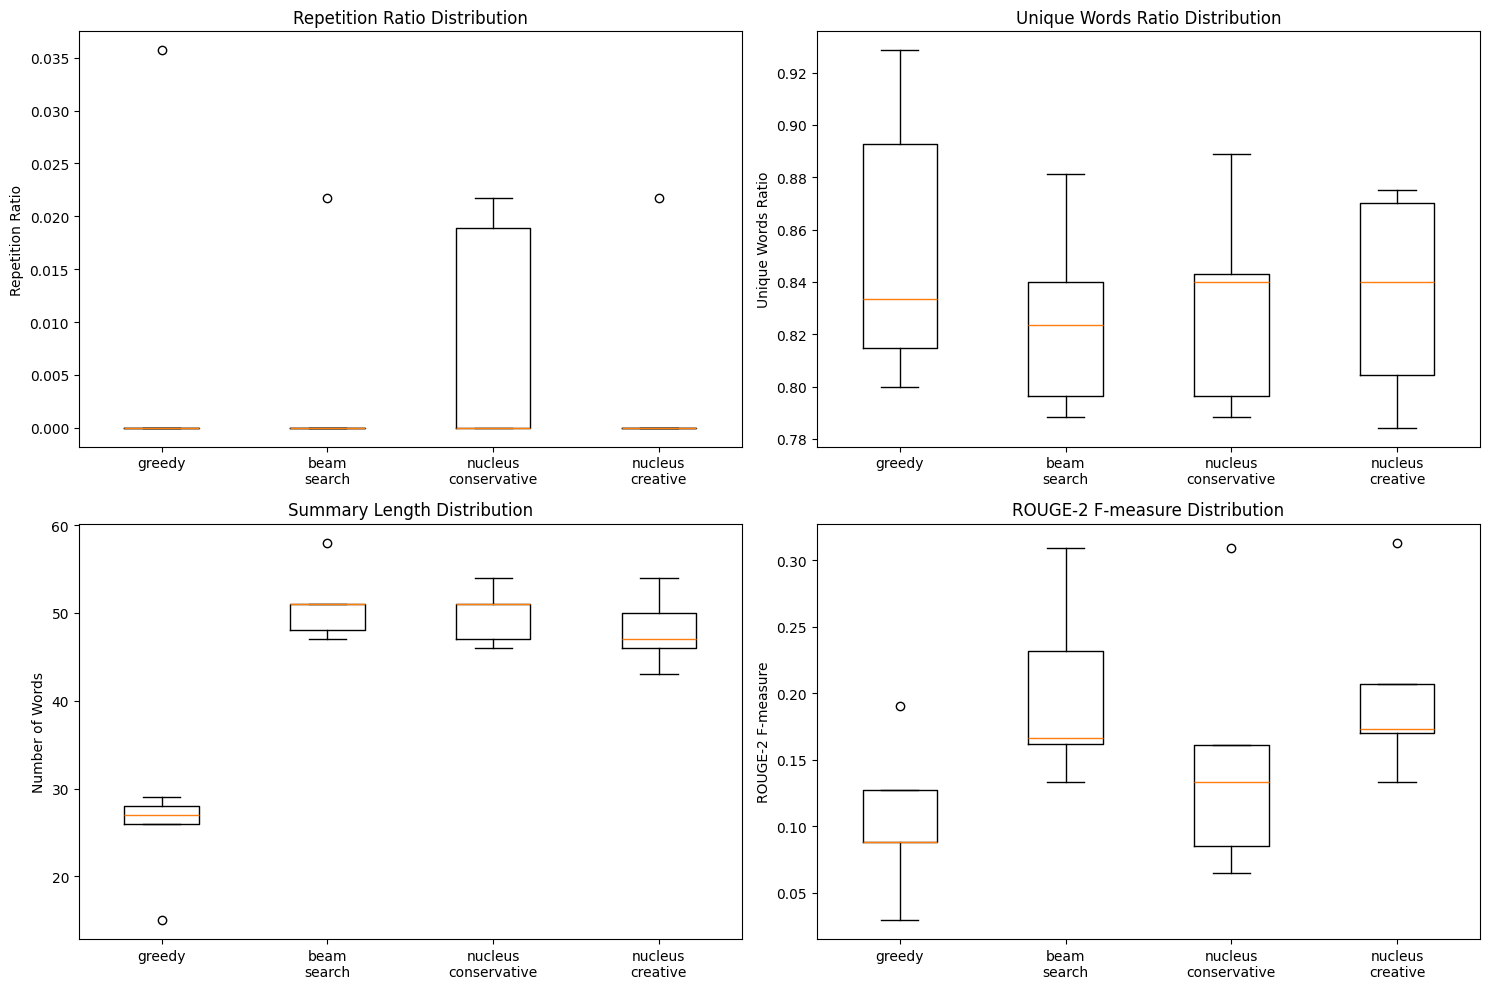


COMPREHENSIVE STRATEGY COMPARISON TABLE:
            Strategy Avg ROUGE-1 Avg ROUGE-2 Avg ROUGE-L Repetition Uniqueness Avg Length
              Greedy       0.338       0.105       0.250      0.007      0.854       25.0
         Beam Search       0.402       0.201       0.320      0.004      0.826       51.0
Nucleus Conservative       0.399       0.151       0.273      0.008      0.831       49.8
    Nucleus Creative       0.405       0.199       0.337      0.004      0.835       48.0


In [38]:
from collections import Counter
import re

def calculate_repetition_ratio(text):
    """Calculate the ratio of repeated bigrams in text"""
    words = text.lower().split()
    if len(words) < 2:
        return 0

    bigrams = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
    bigram_counts = Counter(bigrams)
    repeated_bigrams = sum(count - 1 for count in bigram_counts.values() if count > 1)

    return repeated_bigrams / len(bigrams) if bigrams else 0

def calculate_unique_words_ratio(text):
    """Calculate the ratio of unique words in text"""
    words = re.findall(r'\b\w+\b', text.lower())
    if not words:
        return 0
    return len(set(words)) / len(words)

def calculate_diversity_metrics(comparison_results):
    """Calculate diversity metrics for all strategies"""
    strategies = ['greedy', 'beam_search', 'nucleus_conservative', 'nucleus_creative']

    metrics = {
        strategy: {
            'repetition_ratios': [],
            'unique_word_ratios': [],
            'summary_lengths': [],
            'sentence_counts': []
        } for strategy in strategies
    }

    for result in comparison_results:
        for strategy in strategies:
            summary = result[strategy]

            # Calculate metrics
            metrics[strategy]['repetition_ratios'].append(calculate_repetition_ratio(summary))
            metrics[strategy]['unique_word_ratios'].append(calculate_unique_words_ratio(summary))
            metrics[strategy]['summary_lengths'].append(len(summary.split()))
            metrics[strategy]['sentence_counts'].append(len(re.split(r'[.!?]+', summary)))

    return metrics

# Calculate diversity metrics
diversity_metrics = calculate_diversity_metrics(comparison_results)

# Display diversity analysis
print("DIVERSITY AND QUALITY ANALYSIS")
print("="*60)

strategies = ['greedy', 'beam_search', 'nucleus_conservative', 'nucleus_creative']

for strategy in strategies:
    print(f"\n{strategy.upper()}:")

    avg_repetition = np.mean(diversity_metrics[strategy]['repetition_ratios'])
    avg_unique_ratio = np.mean(diversity_metrics[strategy]['unique_word_ratios'])
    avg_length = np.mean(diversity_metrics[strategy]['summary_lengths'])
    avg_sentences = np.mean(diversity_metrics[strategy]['sentence_counts'])

    print(f"  Average Repetition Ratio: {avg_repetition:.3f}")
    print(f"  Average Unique Words Ratio: {avg_unique_ratio:.3f}")
    print(f"  Average Summary Length: {avg_length:.1f} words")
    print(f"  Average Sentence Count: {avg_sentences:.1f}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Repetition ratio comparison
repetition_data = [diversity_metrics[s]['repetition_ratios'] for s in strategies]
axes[0, 0].boxplot(repetition_data, labels=[s.replace('_', '\n') for s in strategies])
axes[0, 0].set_title('Repetition Ratio Distribution')
axes[0, 0].set_ylabel('Repetition Ratio')

# Unique words ratio comparison
unique_data = [diversity_metrics[s]['unique_word_ratios'] for s in strategies]
axes[0, 1].boxplot(unique_data, labels=[s.replace('_', '\n') for s in strategies])
axes[0, 1].set_title('Unique Words Ratio Distribution')
axes[0, 1].set_ylabel('Unique Words Ratio')

# Summary length comparison
length_data = [diversity_metrics[s]['summary_lengths'] for s in strategies]
axes[1, 0].boxplot(length_data, labels=[s.replace('_', '\n') for s in strategies])
axes[1, 0].set_title('Summary Length Distribution')
axes[1, 0].set_ylabel('Number of Words')

# ROUGE-2 scores comparison
rouge2_data = [rouge_results[s]['rouge2_f'] for s in strategies]
axes[1, 1].boxplot(rouge2_data, labels=[s.replace('_', '\n') for s in strategies])
axes[1, 1].set_title('ROUGE-2 F-measure Distribution')
axes[1, 1].set_ylabel('ROUGE-2 F-measure')

plt.tight_layout()
plt.show()

# Summary table
summary_table_data = []
for strategy in strategies:
    summary_table_data.append({
        'Strategy': strategy.replace('_', ' ').title(),
        'Avg ROUGE-1': f"{np.mean(rouge_results[strategy]['rouge1_f']):.3f}",
        'Avg ROUGE-2': f"{np.mean(rouge_results[strategy]['rouge2_f']):.3f}",
        'Avg ROUGE-L': f"{np.mean(rouge_results[strategy]['rougeL_f']):.3f}",
        'Repetition': f"{np.mean(diversity_metrics[strategy]['repetition_ratios']):.3f}",
        'Uniqueness': f"{np.mean(diversity_metrics[strategy]['unique_word_ratios']):.3f}",
        'Avg Length': f"{np.mean(diversity_metrics[strategy]['summary_lengths']):.1f}"
    })

summary_table_df = pd.DataFrame(summary_table_data)
print("\nCOMPREHENSIVE STRATEGY COMPARISON TABLE:")
print("="*60)
print(summary_table_df.to_string(index=False))